<a href="https://colab.research.google.com/github/ayyucedemirbas/scAnalyzer/blob/main/scAnalyzer_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scAnalysis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 39.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of louvain to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 100.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 96.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 19.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 66.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 57.4 MB/s eta 0:00:00
  Created wheel for lou

In [1]:
import os
import urllib.request
import tarfile
import numpy as np

from scAnalysis import (
    sc_io,
    preprocessing,
    quality_control,
    cell_cycle,
    batch_correction,
    dimensionality,
    clustering,
    trajectory,
    differential,
    enrichment,
    visualization,
    interactive_viz
)

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

In [3]:
def get_pbmc3k_data():
    url = "https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz"
    filepath = "pbmc3k.tar.gz"
    extract_path = "pbmc3k_extracted"

    if not os.path.exists(extract_path):
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req) as response, open(filepath, "wb") as out_file:
            out_file.write(response.read())
        with tarfile.open(filepath, "r:gz") as tar:
            tar.extractall(path=extract_path)

    return os.path.join(extract_path, "filtered_gene_bc_matrices", "hg19")

In [4]:
data_path = get_pbmc3k_data()
data = sc_io.read_10x_mtx(data_path)
data.var.index = sc_io._make_unique(data.var.index.values)
print(f"Loaded {data.n_obs} cells and {data.n_vars} genes.")

IO: data from 'pbmc3k_extracted/filtered_gene_bc_matrices/hg19' …
IO: Loaded 2,700 cells × 32,738 genes.
Loaded 2700 cells and 32738 genes.


In [5]:
preprocessing.calculate_qc_metrics(data, qc_vars=["MT-"])

In [6]:
quality_control.scrublet(data)

Scrublet: Starting doublet detection...
Scrublet: Filtering genes...
Scrublet: Kept 13714/32738 genes
Scrublet: Selected 2057 variable genes
Scrublet: Simulating 5400 doublets...
Scrublet: Normalizing data...
Scrublet: Computing 30 PCs...
Scrublet: Calculating doublet scores...
Scrublet: Detected 151 doublets (5.6%)
Scrublet: Threshold = 0.867


SingleCellDataset object with n_obs × n_vars = 2700 × 32738
    obs: barcode, n_genes_by_counts, total_counts, pct_counts_MT-, doublet_score, predicted_doublet
    var: gene_ids, gene_symbols
    Memory (X): 17.45 MB

In [7]:
mask_singlets = ~data.obs['predicted_doublet'].astype(bool)
data = data[mask_singlets, :]

In [8]:
data = preprocessing.filter_cells(data, min_genes=200, max_pct_mito=5.0)
data = preprocessing.filter_genes(data, min_cells=3)

filter_cells: keeping 2,492 / 2,549 cells.
filter_genes: keeping 13,570 / 32,738 genes.


In [9]:
# ---------------------------------------------------------
# 3. Normalization (Choose ONE of the following methods)
# ---------------------------------------------------------

# Option A: Basic total count normalization (Fastest, traditional approach)
preprocessing.normalize_total(data, target_sum=1e4)

# Option B: scran-like pooling (Recommended for shallow sequencing with many dropouts)
# preprocessing.normalize_scran_pooling(data, target_sum=1e4)

# Option C: sctransform-like regression (Advanced variance stabilization, regresses out sequencing depth)
# Note: If you use sctransform, you typically do NOT need to apply log1p afterwards,
# as the output is already Pearson residuals.
#preprocessing.normalize_sctransform(data)

# ---------------------------------------------------------

# Apply log1p ONLY IF you used Option A or Option B above.
# (Comment this out if you used Option C - sctransform)
preprocessing.log1p(data)

# 4. Cell Cycle Scoring & Feature Selection
cell_cycle.score_cell_cycle(data, organism="human")

SingleCellDataset object with n_obs × n_vars = 2492 × 13570
    obs: barcode, n_genes_by_counts, total_counts, pct_counts_MT-, doublet_score, predicted_doublet, S_score, G2M_score, phase
    var: gene_ids, gene_symbols, n_cells
    Memory (X): 16.11 MB

In [10]:
preprocessing.highly_variable_genes(data, n_top_genes=2000)

HVG: identified 2,000 highly variable genes.


In [11]:
data.raw = data.copy()

In [12]:
preprocessing.scale(data, max_value=10)

/tmp/ipykernel_20567/2775036606.py:1: UserWarning: scale(zero_center=True) densifies the sparse matrix. Consider zero_center=False to preserve sparsity.
  preprocessing.scale(data, max_value=10)


In [13]:
data.obs['batch'] = np.random.choice(['Donor_A', 'Donor_B'], size=data.n_obs)

In [14]:
dimensionality.run_pca(data, n_components=50)
batch_correction.harmony_integrate(data, batch_key='batch', basis='X_pca', adjusted_basis='X_pca_harmony')

PCA: using 2,000 HVGs.
PCA: computed 50 components (16.8% variance explained).
Harmony: 2,492 cells · 50 PCs · 2 batches
  iter  1/10  Δ=0.005070
  iter  2/10  Δ=0.001622
  iter  3/10  Δ=0.000516
  iter  4/10  Δ=0.000811
  iter  5/10  Δ=0.000771
  iter  6/10  Δ=0.000095
  converged.
Harmony: done — corrected embedding in obsm['X_pca_harmony']


SingleCellDataset object with n_obs × n_vars = 2492 × 13570
    obs: barcode, n_genes_by_counts, total_counts, pct_counts_MT-, doublet_score, predicted_doublet, S_score, G2M_score, phase, batch
    var: gene_ids, gene_symbols, n_cells, means, dispersions, dispersions_norm, highly_variable
    uns: pca
    obsm: X_pca, X_pca_harmony
    varm: PCs
    Memory (X): 258.00 MB

In [15]:
dimensionality.neighbors(data, n_neighbors=10, n_pcs=40)
dimensionality.run_umap(data, min_dist=0.3)

Neighbors: k=10, metric='euclidean' …
Neighbors: graph built (2,492 cells).
UMAP: min_dist=0.3, n_components=2 …


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


SingleCellDataset object with n_obs × n_vars = 2492 × 13570
    obs: barcode, n_genes_by_counts, total_counts, pct_counts_MT-, doublet_score, predicted_doublet, S_score, G2M_score, phase, batch
    var: gene_ids, gene_symbols, n_cells, means, dispersions, dispersions_norm, highly_variable
    uns: pca, neighbors
    obsm: X_pca, X_pca_harmony, X_umap
    varm: PCs
    Memory (X): 258.00 MB

In [16]:
clustering.cluster_leiden(data, resolution=0.5, key_added="leiden")

Clustering: Leiden resolution=0.5 …
Leiden: found 6 clusters.


SingleCellDataset object with n_obs × n_vars = 2492 × 13570
    obs: barcode, n_genes_by_counts, total_counts, pct_counts_MT-, doublet_score, predicted_doublet, S_score, G2M_score, phase, batch, leiden
    var: gene_ids, gene_symbols, n_cells, means, dispersions, dispersions_norm, highly_variable
    uns: pca, neighbors
    obsm: X_pca, X_pca_harmony, X_umap
    varm: PCs
    Memory (X): 258.00 MB

In [17]:
dimensionality.run_diffmap(data)

Diffusion map: computing 15 components ...
Diffusion map: done.  Top eigenvalue gap: 0.9995 → 0.9946.


SingleCellDataset object with n_obs × n_vars = 2492 × 13570
    obs: barcode, n_genes_by_counts, total_counts, pct_counts_MT-, doublet_score, predicted_doublet, S_score, G2M_score, phase, batch, leiden
    var: gene_ids, gene_symbols, n_cells, means, dispersions, dispersions_norm, highly_variable
    uns: pca, neighbors, diffmap_evals
    obsm: X_pca, X_pca_harmony, X_umap, X_diffmap
    varm: PCs
    Memory (X): 258.00 MB

In [18]:
root_idx = trajectory.select_root_cell(data, cluster_key='leiden', root_cluster='0', strategy='extreme')
trajectory.diffusion_pseudotime(data, root_cell=root_idx)

trajectory: root cell selected = index 468 (obs 'AGGGCGCTATGGTC-1', cluster='0', strategy='extreme').
DPT: using pre-computed diffusion map.
DPT: pseudotime stored in obs['dpt_pseudotime']. Root cell = 468 (t=0).


SingleCellDataset object with n_obs × n_vars = 2492 × 13570
    obs: barcode, n_genes_by_counts, total_counts, pct_counts_MT-, doublet_score, predicted_doublet, S_score, G2M_score, phase, batch, leiden, dpt_pseudotime
    var: gene_ids, gene_symbols, n_cells, means, dispersions, dispersions_norm, highly_variable
    uns: pca, neighbors, diffmap_evals
    obsm: X_pca, X_pca_harmony, X_umap, X_diffmap
    varm: PCs
    Memory (X): 258.00 MB

In [19]:
differential.rank_genes_groups(data, groupby='leiden', method='t-test', use_raw=True)
cluster0_markers = differential.get_marker_genes(data, group='0', pval_cutoff=0.05, lfc_cutoff=0.5)
print(f"Top 3 significant markers for Cluster 0: {cluster0_markers.head(3)}")

Differential: Ranking genes for 6 groups using t-test (use_raw=True) …
  … processing group '0'
  … processing group '3'
  … processing group '1'
  … processing group '2'
  … processing group '4'
  … processing group '5'
Top 3 significant markers for Cluster 0:    names     scores  logfoldchanges          pvals      pvals_adj    pct_in  \
0   LDHB  39.400017        1.507539  4.523873e-264  2.046299e-260  0.918404   
1   CD3D  38.842580        1.580856  2.852203e-257  9.676098e-254  0.870354   
2  RPS12  34.188869        0.742297  2.394176e-205  3.248897e-202  1.000000   

    pct_out  
0  0.464363  
1  0.223182  
2  0.987761  


In [20]:
canonical_markers = {
    'T_cell': ['CD3D', 'CD3E', 'CD3G'],
    'B_cell': ['CD19', 'MS4A1', 'CD79A'],
    'Monocyte': ['CD14', 'LYZ', 'S100A8']
}

In [21]:
enrichment_results = enrichment.rank_genes_groups_by_enrichment(data, canonical_markers, groupby='leiden')

In [22]:
visualization.plot_umap(data, color="leiden", title="PBMC 3k - Leiden Clusters", save="umap_clusters.png")

Saved → umap_clusters.png


<Axes: title={'center': 'PBMC 3k - Leiden Clusters'}, xlabel='X_umap 1', ylabel='X_umap 2'>

In [23]:
visualization.plot_umap(data, color="phase", title="Cell Cycle Phase Distribution", save="umap_phase.png")

Saved → umap_phase.png


<Axes: title={'center': 'Cell Cycle Phase Distribution'}, xlabel='X_umap 1', ylabel='X_umap 2'>

Saved → volcano_cluster0.png


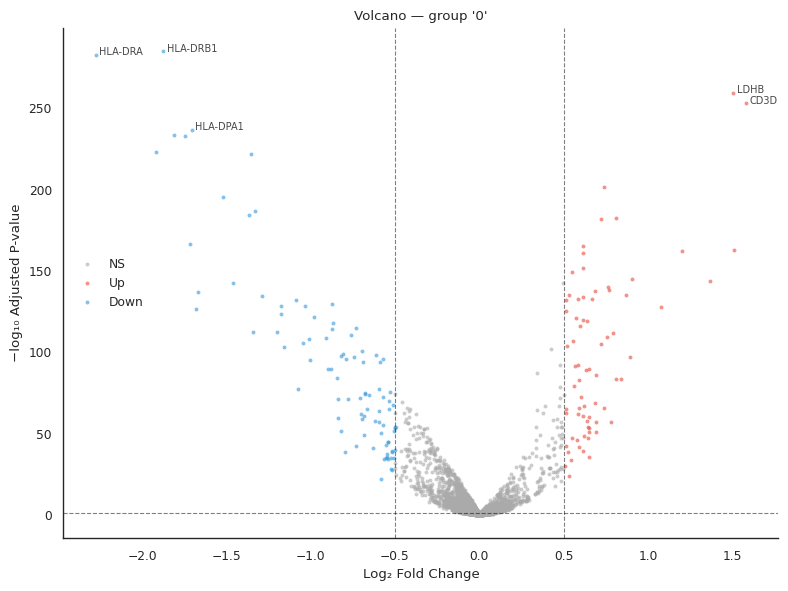

In [24]:
visualization.volcano_plot(data, group='0', top_n_genes=5, save="volcano_cluster0.png")

In [25]:
available_markers = [g for g in ['CD3E', 'MS4A1', 'CD14', 'LYZ', 'GNLY'] if g in data.var.index]
if available_markers:
    visualization.plot_dotplot(data, var_names=available_markers, groupby='leiden', save="dotplot_markers.png")

Saved → dotplot_markers.png


In [26]:
try:
    interactive_viz.interactive_embedding(
        data,
        basis='X_umap',
        color='leiden',
        hover_data=['n_genes_by_counts', 'phase', 'dpt_pseudotime'],
        title="PBMC 3k - Interactive UMAP",
        save_html="interactive_umap.html"
    )
except Exception as e:
    print(f"Skipping interactive plots (Plotly may not be installed): {e}")

Interactive plot saved to interactive_umap.html


In [27]:
output_file = "pbmc3k_full_analysis.h5ad"
sc_io.write_h5ad(data, output_file)

IO: Writing H5AD -> 'pbmc3k_full_analysis.h5ad' ...
IO: Wrote 2,492 cells × 13,570 genes.
